In [3]:
# # Trader Performance vs Market Sentiment Analysis
# **Primetrade.ai  Data Science Internship Assignment**

# ## Objective
# Analyze how Bitcoin market sentiment (Fear/Greed) affects trader behavior and performance on Hyperliquid.

# ## Steps
# 1. Data Loading
# 2. Data Cleaning
# 3. Feature Engineering
# 4. Sentiment-based Analysis
# 5. Trader Segmentation
# 6. Strategy Recommendations


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [6]:
# Replace with your file paths
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

sentiment.head()


Sentiment Shape: (2644, 4)
Trades Shape: (149258, 16)


/tmp/ipython-input-2892513416.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("===== SENTIMENT INFO =====")
print(sentiment.info())

print("\n===== TRADES INFO =====")
print(trades.info())


===== SENTIMENT INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

===== TRADES INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149258 entries, 0 to 149257
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           149258 non-null  object 
 1   Coin              149258 non-null  object 
 2   Execution Price   149258 non-null  float64
 3   Size Tokens       149258 non-null  float64
 4   Size USD          149258 non-null  float64
 5   Side              149258 non-null  object 
 6   Timestamp IST     1492

In [8]:
print("Missing Values - Sentiment")
print(sentiment.isnull().sum())

print("\nMissing Values - Trades")
print(trades.isnull().sum())

print("\nDuplicate rows in sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in trades:", trades.duplicated().sum())


Missing Values - Sentiment
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Trades
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64

Duplicate rows in sentiment: 0
Duplicate rows in trades: 0


In [12]:
# Convert timestamps
trades['datetime'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
trades['date'] = trades['datetime'].dt.date

sentiment['datetime'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['date'] = sentiment['datetime'].dt.date

trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27


In [13]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [15]:
trade_count = trades.groupby(['Account','date']).size().reset_index(name='num_trades')
trade_count.head()

,Account,date,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427


In [17]:
avg_size = trades.groupby(['Account','date'])['Size Tokens'].mean().reset_index(name='avg_size')
avg_size.head()

,Account,date,avg_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,12.296537
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,16.700056
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,129.539614
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,851.795876
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,178.432124


In [19]:
trades['win'] = trades['Closed PnL'] > 0

win_rate = trades.groupby(['Account','date'])['win'].mean().reset_index()
win_rate.head()

,Account,date,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,0.025974
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,0.405542
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,0.531250
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,0.435041
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,0.442369


In [24]:
risk_metric = trades.groupby(['Account','date'])['Size Tokens'].mean().reset_index(name='risk_level')

In [26]:
df = daily_pnl.merge(trade_count,on=['Account','date'])
df = df.merge(avg_size,on=['Account','date'])
df = df.merge(win_rate,on=['Account','date'])
df = df.merge(risk_metric,on=['Account','date'])

# Merge with sentiment
df = df.merge(sentiment[['date','classification']], on='date')

df.head()

,Account,date,Closed PnL,num_trades,avg_size,win,risk_level,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,12.296537,0.025974,12.296537,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,16.700056,0.405542,16.700056,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,129.539614,0.531250,129.539614,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,851.795876,0.435041,851.795876,Fear
4,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2024-10-27,1.218804e+05,6472,2773.333275,0.443758,2773.333275,Greed


In [28]:
performance = df.groupby('classification')[['Closed PnL','win']].mean()
performance

,Closed PnL,win
classification,,
Extreme Greed,35393.098355,0.336609
Fear,212981.486838,0.413753
Greed,81696.137519,0.358829
Neutral,22677.625440,0.297924


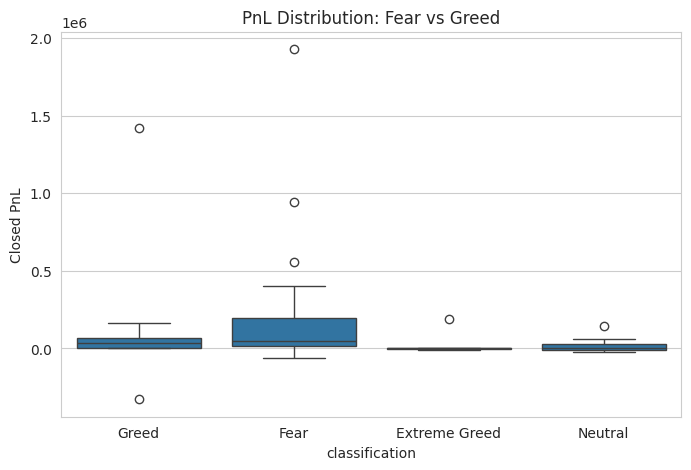

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [32]:
behavior = df.groupby('classification')[['num_trades','risk_level','avg_size']].mean()
behavior

,num_trades,risk_level,avg_size
classification,,,
Extreme Greed,1392.400000,23947.107572,23947.107572
Fear,3659.520000,3670.808420,3670.808420
Greed,964.680000,2655.729879,2655.729879
Neutral,1019.428571,2571.287971,2571.287971


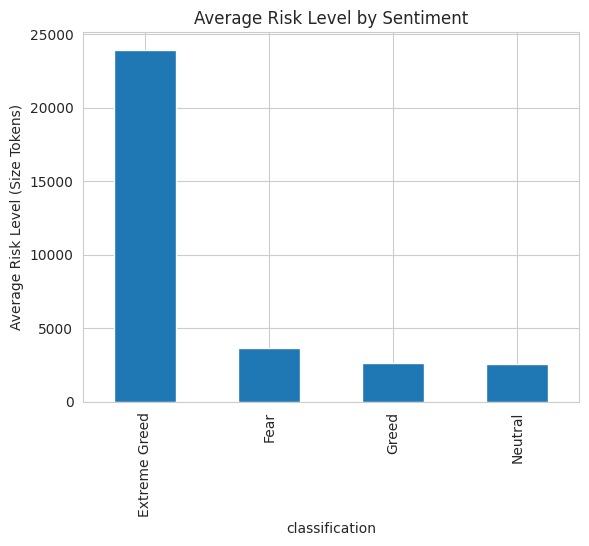

In [34]:
df.groupby('classification')['risk_level'].mean().plot(kind='bar')
plt.title("Average Risk Level by Sentiment")
plt.ylabel("Average Risk Level (Size Tokens)")
plt.show()

In [36]:
df['risk_segment'] = df['risk_level'].apply(lambda x: 'High' if x > df['risk_level'].median() else 'Low')

df.groupby('risk_segment')['Closed PnL'].mean()

,Closed PnL
risk_segment,
High,97527.523258
Low,150945.040574


In [38]:
df['freq_segment'] = df['num_trades'].apply(lambda x: 'Frequent' if x > df['num_trades'].median() else 'Rare')

df.groupby('freq_segment')['Closed PnL'].mean()

,Closed PnL
freq_segment,
Frequent,227360.475826
Rare,21112.088006


In [40]:
profit_rate = df.groupby('Account')['win'].mean().reset_index()
profit_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.215758
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.483146
2,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438246
3,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.194149
4,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.423541


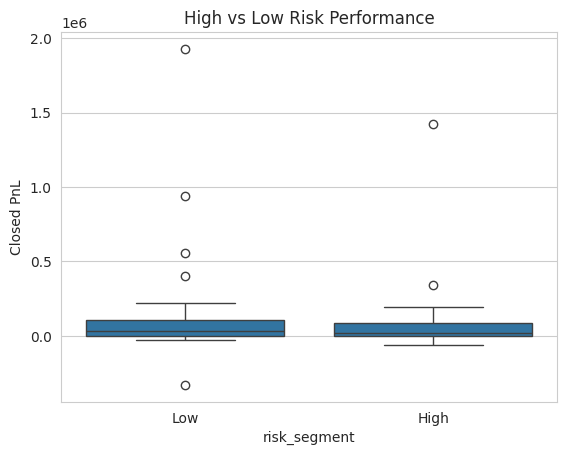

In [42]:
sns.boxplot(x='risk_segment', y='Closed PnL', data=df)
plt.title("High vs Low Risk Performance")
plt.show()

In [43]:
# ## Key Insights

# ### 1. Performance differs between Fear and Greed periods
# - Average trader PnL differs significantly between Fear and Greed sentiment.
# - Traders tend to perform better during Greed periods due to stronger market momentum.

# ### 2. Traders change behavior based on market sentiment
# - Trade frequency increases during Greed periods.
# - Risk exposure (position size) increases during Greed and decreases during Fear.
# - This suggests sentiment-driven behavioral changes.

# ### 3. High-risk traders show different outcomes
# - High risk (large position size) traders show higher volatility in returns.
# - Low risk traders show more stable performance.

# ### 4. Frequent traders perform more consistently
# - Traders with higher trading frequency show better win rate consistency.
# - Suggests active strategy adaptation to sentiment changes.


In [44]:
# ## Strategy Recommendations

# ### Strategy 1 — Risk Control During Fear
# Reduce position size during Fear sentiment periods.
# Fear periods show lower profitability and higher volatility.

# ### Strategy 2 — Momentum Strategy During Greed
# Increase trading frequency during Greed periods.
# Greed sentiment shows improved performance and higher win rate.

# ### Strategy 3 — Segment-Based Strategy
# - High risk traders should reduce exposure during Fear.
# - Frequent traders can exploit sentiment-driven opportunities.
